In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

fits.info("M41.fits")

header = fits.getheader("M41.fits", ext=2)
header["EXPTIME"] #obtener el tiempo de exposición de la imagen

Filename: M41.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (3096, 2080)   float64   
  1                1 ImageHDU        36   (3096, 2080)   float64   
  2                1 ImageHDU        36   (3096, 2080)   float64   


5.0

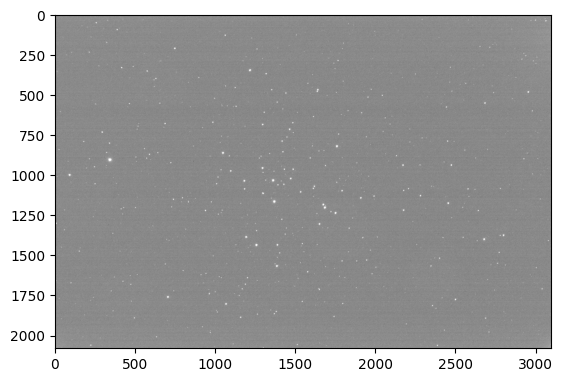

In [3]:
image = fits.getdata("M41.fits",ext=2) #obtener los datos de la imagen y aplanarlos en un vector

plt.imshow(image, cmap="grey", norm="log",vmax=700
           
           )
#cast it into an image

(array([0.000000e+00, 1.000000e+00, 1.000000e+00, 4.000000e+00,
        2.200000e+01, 6.100000e+01, 2.100000e+02, 8.420000e+02,
        9.275000e+03, 1.091080e+05, 6.457430e+05, 1.740696e+06,
        2.159091e+06, 1.280070e+06, 3.931940e+05, 7.294000e+04,
        1.147800e+04, 3.209000e+03, 1.792000e+03, 1.325000e+03,
        1.061000e+03, 8.210000e+02, 7.270000e+02, 5.410000e+02,
        4.790000e+02, 4.410000e+02, 3.630000e+02, 3.300000e+02,
        2.870000e+02, 2.880000e+02, 2.340000e+02, 2.240000e+02,
        1.710000e+02, 1.940000e+02, 1.780000e+02, 1.410000e+02,
        1.420000e+02, 1.350000e+02, 1.290000e+02, 1.200000e+02,
        9.400000e+01, 9.900000e+01, 9.200000e+01, 8.200000e+01,
        9.400000e+01, 7.400000e+01, 6.300000e+01, 6.600000e+01,
        8.100000e+01]),
 array([ 100.        ,  118.36734694,  136.73469388,  155.10204082,
         173.46938776,  191.83673469,  210.20408163,  228.57142857,
         246.93877551,  265.30612245,  283.67346939,  302.04081633,
    

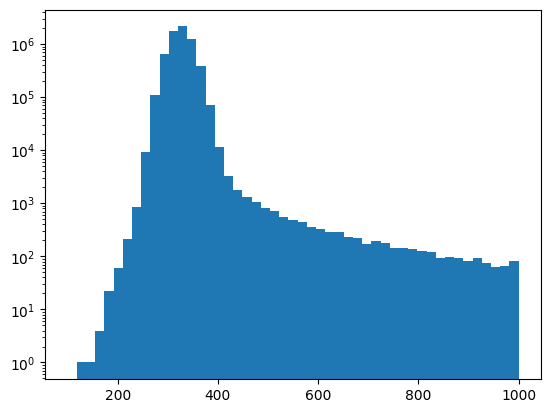

In [4]:

#cast into an histogram with log scale
plt.hist(image.ravel(), bins=np.linspace(100,1000), log=True)


##Day 2

Ahora voy a trabajar con la imágen de Santiago como un array, supongo?

Quiero encontrar los peaks locales para la imágen

 id x_peak y_peak     peak_value    
--- ------ ------ ------------------
  1   1060    131 2579.6512756347656
  2    746    213  6616.357666015625
  3   1763    289   2315.34521484375
  4   1215    348  24982.70947265625
  5    574    354 1744.2494201660156
  6   1315    371  5753.323791503906
  7    628    401 1620.2465209960938
  8   1575    431 1494.3108825683594
  9   1122    458 2090.7156982421875
 10   1350    471 3499.3018188476562
...    ...    ...                ...
140   3093   1870  2258.871124267578
141   3089   1875 2084.1454734802246
142   1738   1884 2463.4076232910156
143   1156   1888  5603.308044433594
144    494   1892 1930.4323425292969
145   2683   1893  2480.812469482422
146   2703   1980  1538.810043334961
147    967   1983 1760.2778625488281
148   1509   2058 3154.3599548339844
149   2382   2063 3672.5911865234375
Length = 149 rows


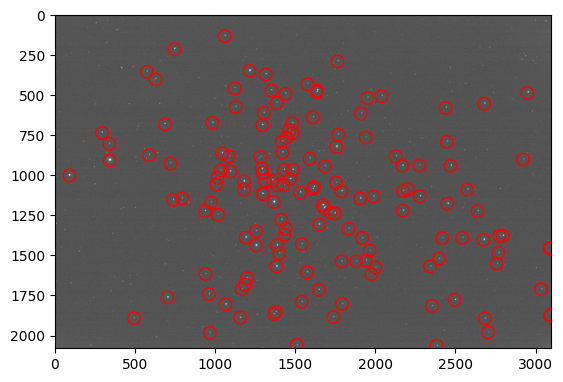

In [5]:
#importamos la librerpía que voy a necesitar

import photutils
from photutils.detection import find_peaks
from photutils.datasets import make_100gaussians_image

#haciendo el ejemplo de https://photutils.readthedocs.io/en/latest/user_guide/detection.html#:~:text=Local%20Peak%20Detection,centroid%20coordinates%20with%20subpixel%20precision.


#crear los parámetros para la detección de picos

mean, median, std = np.mean(image), np.median(image), np.std(image)#parámetros gausianos de la imagen
threshold = median + (5. * std) #umbral para la detección de picos, se puede ajustar dependiendo de la imagen
#son 5 sigma más arriba 

#encontrar los picos en la imagen
peaks_tbl = find_peaks(image, threshold=threshold, box_size=5)

#mostrar los picos encontrados
print(peaks_tbl)

#plotear los picos encontrados en la imagen
plt.imshow(image, cmap="gray", norm="log", vmax=2000)
plt.scatter(peaks_tbl["x_peak"], peaks_tbl["y_peak"], s=80, edgecolor="red", facecolor="none")



Get the FWHM for all 30 quadrants and then work with the median and average. 
work with th epeaks for RGB magnitudes
Mag in time involves dividing the flow by the expo time (25sec) 
You can pair them in topcat using the match function 
40 pixels for the radius
After getting the color magnitude diagram, combine them and confirm where the graph is present within the Gaia dataset. 


##

Ahora voy a hacer lo mismo pero sin utilizar la librería de photutils o astropy.


In [6]:
#importanto lo de que necesito
from skimage.feature import peak_local_max
from photutils.centroids import centroid_quadratic

#tomar un threshold para la detección de picos, a mano es esa mondá
threshold_peaklocalmax = 500
#guardar los picos encontrados en un array
local_max_array = peak_local_max(image, min_distance=5, threshold_abs=threshold_peaklocalmax)

#ahora castear esa mondá a centroid cuadratic
centroid_max_array = []
#hacer un loop para castear cada pico encontrado a centroid cuadratic
for x, y in local_max_array:
    centroid_x, centroid_y = centroid_quadratic(image, ypeak=x, xpeak=y, fit_boxsize=5).T
    centroid_max_array.append((centroid_x, centroid_y))


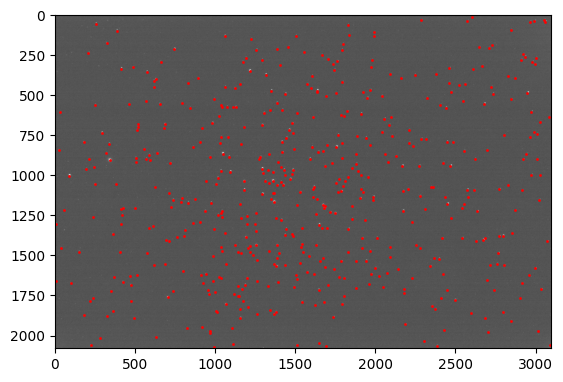

In [7]:
#ahora a graficarlo
plt.imshow(image, cmap="gray", norm="log", vmax=2000)

#agregar los centroides encontrados
for x, y in centroid_max_array:
    plt.plot(x, y, "o", color="red", markersize=1)

In [8]:
#partir la imagen en 30 partes iguales

nx, ny = image.shape
n_y=6
n_x=5
step_y = ny // n_y
step_x = nx // n_x

#ahora a graficar cada parte de la imagen con los centroides encontrados
global_peaks =[]

for i in range(n_y):
    for j in range(n_x):
        #definir los límites de la imágen.
        y_min = i * step_y
        y_max = (i + 1) * step_y
        x_min = j * step_x
        x_max = (j + 1) * step_x

        #extraer la parte de la imagen
        sub_image = image[y_min:y_max, x_min:x_max]

        #encontrar los picos en la parte de la imagen
        local_peaks = peak_local_max(sub_image, min_distance=5, threshold_abs=threshold_peaklocalmax)

        #convertir coordenadas locales a globales
        for x_local, y_local in local_peaks:
            x_global = x_local + x_min
            y_global = y_local + y_min
            global_peaks.append((x_global, y_global))


In [9]:
#fotometría de apertura

from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus, aperture_photometry

posiciones = [(cx, cy) for cx, cy in centroid_max_array]

aperturas = CircularAperture(posiciones, r=10) #radio de la apertura, se puede ajustar dependiendo de la imagen

phot_table = aperture_photometry(image, aperturas)

#ésto crea un DataFrame con las posiciones de los centroides y 
# la suma de los valores de los píxeles dentro de cada apertura, 
# lo que nos da una medida de la intensidad de cada fuente detectada.

print(phot_table)

 id      xcenter            ycenter          aperture_sum   
--- ------------------ ------------------ ------------------
  1  341.9624137722437  906.6542936343592 2565372.9887251565
  2 1366.0422851547853  1167.000976957022 1004443.3738462767
  3 1358.9315174558797 1035.0800147601517  831411.8138986371
  4  1254.902806518772 1437.7383092825169  672561.8448463171
  5  1681.267396834979 1204.2637882156387  573901.1407949075
  6 1756.1969503618566  822.6726584617276  525698.2400318917
  7 1046.2906543440636  863.9767457249658  538636.6556358496
  8  703.2558691826788 1761.5081852856179  482504.4523427545
  9 1382.1352484518072 1568.7487007057262   407584.796019371
 10 1747.7994168979867 1238.0642845215975 379896.50710751966
...                ...                ...                ...
519   805.907973474561  1381.104658154188 103170.94959381488
520 2851.5878427559232 1362.7606806962463 103286.86383573271
521 1045.1496644631043 1471.3808078635223 103316.68947638242
522 1102.2229640100202  

In [10]:
#Entonces, tenemos 528 estrellas detectadas en la imagen, cada una con su posición 
# y su intensidad medida a través de la fotometría de apertura.

#ahora toca restar el backround, para eso se acordó usar un FHWM promedio y usar astropy porque si no
#toca consturir una función que reste el background a cada fuente detectada,

sigmas = []
size = 5

for cx, cy in posiciones:
    # Definimos la vecindad de la estrella
    cutout = image[int(cy-size):int(cy+size+1), int(cx-size):int(cx+size+1)]
    
    # Calculamos la desviación estándar espacial (weighted sigma)
    # Usamos los índices como coordenadas
    y, x = np.mgrid[:cutout.shape[0], :cutout.shape[1]]
    mu = np.sum(cutout)
    if mu <= 0: continue # Evitar ruido
    
    # Sigma en X y Y
    std_x = np.sqrt(np.sum(cutout * (x - size)**2) / mu)
    std_y = np.sqrt(np.sum(cutout * (y - size)**2) / mu)
    
    sigmas.append((std_x + std_y) / 2)

fwhm_promedio = 2.355 * np.median(sigmas)
print(f"FWHM calculado via Sigma: {fwhm_promedio:.2f}")



FWHM calculado via Sigma: 7.13


In [11]:
#radio de apertura
r_apertura = fwhm_promedio * 2.5

r_interno = r_apertura + 2
r_externo = r_apertura + 5 #5 pixeles de radio

#crear la apertura
aperturas = CircularAperture(posiciones, r=r_apertura)
anillos = CircularAnnulus(posiciones, r_interno, r_externo)

#realizar la fotometría de apertura con ambos
photometry_table =  aperture_photometry(image, [aperturas, anillos])
photometry_table

id,xcenter,ycenter,aperture_sum_0,aperture_sum_1
int64,float64,float64,float64,float64
1,341.9624137722437,906.6542936343592,2823340.0193202673,136224.48284301424
2,1366.0422851547853,1167.000976957022,1241092.956972525,133299.01673343717
3,1358.9315174558797,1035.0800147601517,1063105.0416905554,132919.40509850683
4,1254.902806518772,1437.7383092825169,901710.4385960362,131643.14543213553
5,1681.267396834979,1204.2637882156387,813919.127464561,305806.28732046834
6,1756.1969503618566,822.6726584617276,753376.1936516606,131526.60634726722
7,1046.2906543440636,863.9767457249658,766892.8023712251,131767.53492272706
8,703.2558691826788,1761.5081852856179,711529.8262635947,131644.99456552393
9,1382.1352484518072,1568.7487007057262,639378.074929454,131798.14386045176


In [12]:
#ahora hay que extraer el cielo

#se toman las áreas de aperura
area_apertura = aperturas.area
area_anillo = anillos.area

#flujo promedio del cielo por píxel
backround_cielo_pixel = photometry_table["aperture_sum_1"] / area_anillo

#se resta el fondo a la apertura central
flujo_neto = photometry_table["aperture_sum_0"] - (backround_cielo_pixel * area_apertura)

#append a la tabla de fotometría el flujo neto
photometry_table["flujo_neto"] = flujo_neto


In [13]:
#pasar a magnitudes

#evitar logaritmos de números negativos o cero
photometry_table["mag_inst"] = -2.5 * np.log10(photometry_table["flujo_neto"].clip(min=1e-10))

print(photometry_table["id", "xcenter", "ycenter", "flujo_neto", "mag_inst"])

 id      xcenter            ycenter           flujo_neto           mag_inst     
--- ------------------ ------------------ ------------------ -------------------
  1  341.9624137722437  906.6542936343592 2485030.6310556144 -15.988329365788509
  2 1366.0422851547853  1167.000976957022  910048.8754226757 -14.897661793320218
  3 1358.9315174558797 1035.0800147601517  733003.7141692857 -14.662765438100564
  4  1254.902806518772 1437.7383092825169  574778.6634047579  -14.39875159534317
  5  1681.267396834979 1204.2637882156387  54458.45026678592 -11.840163195972975
  6 1756.1969503618566  822.6726584617276  426733.8397574052 -14.075392708842596
  7 1046.2906543440636  863.9767457249658  439652.1096374439 -14.107772903570972
  8  703.2558691826788 1761.5081852856179  384593.4588054022 -13.962504733629807
  9 1382.1352484518072 1568.7487007057262 312061.36582342495 -13.735600012433286
 10 1747.7994168979867 1238.0642845215975  281598.9741492259  -13.62407767090049
...                ...      

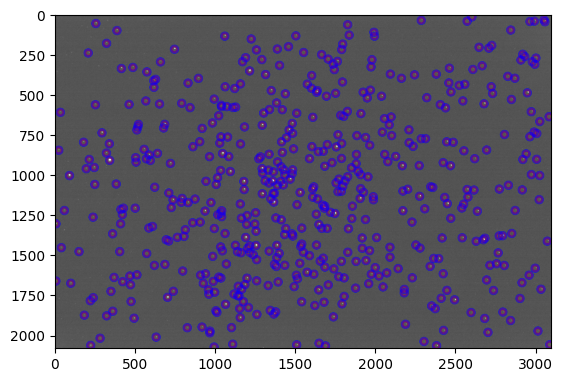

In [14]:
#imagen de las esferas de apertura
plt.imshow(image, cmap="gray", norm="log", vmax=2000)
aperturas.plot(color="red", lw=1.5, alpha=0.5)
anillos.plot(color="blue", lw=1.5, alpha=0.5)
plt.show()


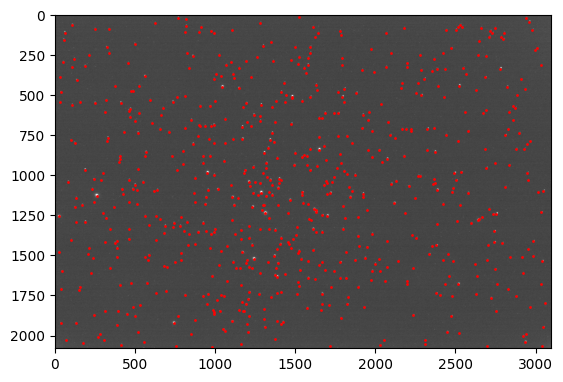

In [15]:
#ahora hacemos lo mismo con la imagen en filtros rojo y azul

#rojo

image_red = fits.getdata("M41.fits", ext=1)

#encontrar picos locales de la misma manera que antes

threshold_peaklocalmax_red = 500

local_max_array_red = peak_local_max(image_red, min_distance=5, threshold_abs=threshold_peaklocalmax_red)

centroid_max_array_red = []
for x, y in local_max_array_red:
    centroid_x, centroid_y = centroid_quadratic(image_red, ypeak=x, xpeak=y, fit_boxsize=5).T
    centroid_max_array_red.append((centroid_x, centroid_y))

#ahora a graficarlo

plt.imshow(image_red, cmap="gray", norm="log", vmax=2000)

#agregar los centroides encontrados
for x, y in centroid_max_array_red:
    plt.plot(x, y, "o", color="red", markersize=1)

FWHM calculado via Sigma para la imagen roja: 7.12


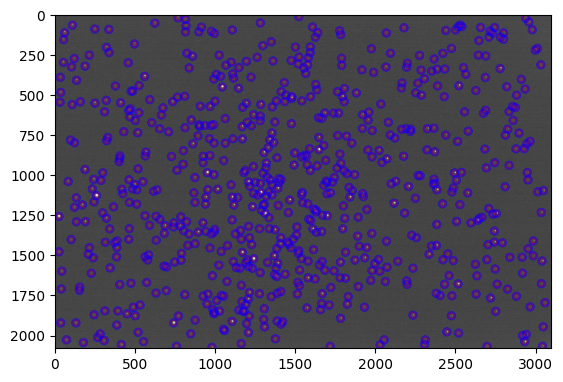

In [16]:
#de nuevo, partir la imagen en 30 partes iguales
nx_red, ny_red = image_red.shape
n_y_red=6
n_x_red=5
step_y_red = ny_red // n_y_red
step_x_red = nx_red // n_x_red

#graficar de nuevo
global_peaks_red =[]

for i in range(n_y_red):
    for j in range(n_x_red):
        #definir los límites de la imágen.
        y_min = i * step_y_red
        y_max = (i + 1) * step_y_red
        x_min = j * step_x_red
        x_max = (j + 1) * step_x_red

        #extraer la parte de la imagen
        sub_image_red = image_red[y_min:y_max, x_min:x_max]

        #encontrar los picos en la parte de la imagen
        local_peaks_red = peak_local_max(sub_image_red, min_distance=5, threshold_abs=threshold_peaklocalmax_red)

        #convertir coordenadas locales a globales
        for x_local, y_local in local_peaks_red:
            x_global = x_local + x_min
            y_global = y_local + y_min
            global_peaks_red.append((x_global, y_global))

#fotometría de apertura para la imagen roja

posiciones_red = [(cx, cy) for cx, cy in centroid_max_array_red]

aperturas_red = CircularAperture(posiciones_red, r=10) #radio de la apertura, se puede ajustar dependiendo de la imagen 

phot_table_red = aperture_photometry(image_red, aperturas_red)

#restar el backround para la imagen roja

sigmas_red = []
size_red = 5

for cx, cy in posiciones_red:
    # Definimos la vecindad de la estrella
    cutout_red = image_red[int(cy-size_red):int(cy+size_red+1), int(cx-size_red):int(cx+size_red+1)]
    
    # Calculamos la desviación estándar espacial (weighted sigma)
    # Usamos los índices como coordenadas
    y, x = np.mgrid[:cutout_red.shape[0], :cutout_red.shape[1]]
    mu = np.sum(cutout_red)
    if mu <= 0: continue # Evitar ruido
    
    # Sigma en X y Y
    std_x = np.sqrt(np.sum(cutout_red * (x - size_red)**2) / mu)
    std_y = np.sqrt(np.sum(cutout_red * (y - size_red)**2) / mu)
    
    sigmas_red.append((std_x + std_y) / 2)
fwhm_promedio_red = 2.355 * np.median(sigmas_red)
print(f"FWHM calculado via Sigma para la imagen roja: {fwhm_promedio_red:.2f}")

#fotometría de apertura para la imagen roja con el nuevo FWHM

r_apertura_red = fwhm_promedio_red * 2.5

r_interno_red = r_apertura_red + 2
r_externo_red = r_apertura_red + 5 #5 pixeles de radio

#crear la apertura
aperturas_red = CircularAperture(posiciones_red, r=r_apertura_red)
anillos_red = CircularAnnulus(posiciones_red, r_interno_red, r_externo_red)

#realizar la fotometría de apertura con ambos
photometry_table_red =  aperture_photometry(image_red, [aperturas_red, anillos_red])

#extraer el cielo para la imagen roja

area_apertura_red = aperturas_red.area
area_anillo_red = anillos_red.area

backround_cielo_pixel_red = photometry_table_red["aperture_sum_1"] / area_anillo_red

flujo_neto_red = photometry_table_red["aperture_sum_0"] - (backround_cielo_pixel_red * area_apertura_red)

photometry_table_red["flujo_neto"] = flujo_neto_red

#pasar a magnitudes para la imagen roja

photometry_table_red["mag_inst"] = -2.5 * np.log10(photometry_table_red["flujo_neto"].clip(min=1e-10))  

#imagen de las esferas de apertura para la imagen roja

plt.imshow(image_red, cmap="gray", norm="log", vmax=2000)
aperturas_red.plot(color="red", lw=1.5, alpha=0.5)
anillos_red.plot(color="blue", lw=1.5, alpha=0.5)
plt.show()
    

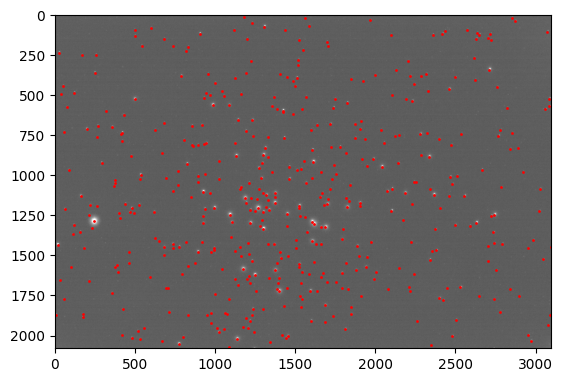

In [17]:
#ahora lo mismo para la imagen azul

image_blue = fits.getdata("M41.fits", ext=0)

#picos locales para la imagen azul
threshold_peaklocalmax_blue = 500

local_max_array_blue = peak_local_max(image_blue, min_distance=5, threshold_abs=threshold_peaklocalmax_blue)    
centroid_max_array_blue = []
for x, y in local_max_array_blue:
    centroid_x, centroid_y = centroid_quadratic(image_blue, ypeak=x, xpeak=y, fit_boxsize=5).T
    centroid_max_array_blue.append((centroid_x, centroid_y))
#graficar la imagen azul con los centroides encontrados
centroid_array_blue = np.array(centroid_max_array_blue)

mask = np.isfinite(centroid_array_blue).all(axis=1)
centroid_array_blue_clean = centroid_array_blue[mask]
plt.imshow(image_blue, cmap="gray", norm="log", vmax=2000)
for x, y in centroid_max_array_blue:
    plt.plot(x, y, "o", color="red", markersize=1)  

FWHM calculado via Sigma para la imagen azul: 7.07


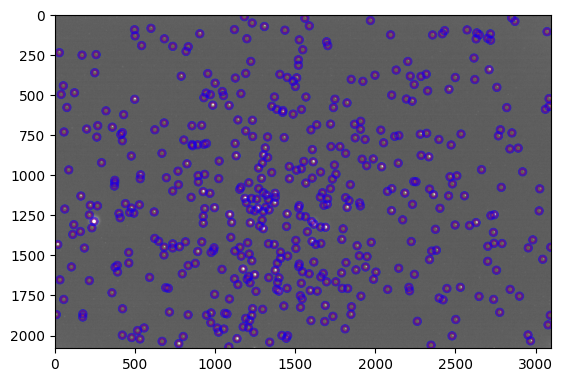

In [18]:
#partir la imagen azul en 30 partes iguales
nx_blue, ny_blue = image_blue.shape
n_y_blue=6              
n_x_blue=5
step_y_blue = ny_blue // n_y_blue
step_x_blue = nx_blue // n_x_blue   

global_peaks_blue =[]

for i in range(n_y_blue):
    for j in range(n_x_blue):
        #definir los límites de la imágen.
        y_min = i * step_y_blue
        y_max = (i + 1) * step_y_blue
        x_min = j * step_x_blue
        x_max = (j + 1) * step_x_blue

        #extraer la parte de la imagen
        sub_image_blue = image_blue[y_min:y_max, x_min:x_max]

        #encontrar los picos en la parte de la imagen
        local_peaks_blue = peak_local_max(sub_image_blue, min_distance=5, threshold_abs=threshold_peaklocalmax_blue)

        #convertir coordenadas locales a globales
        for x_local, y_local in local_peaks_blue:
            x_global = x_local + x_min
            y_global = y_local + y_min
            global_peaks_blue.append((x_global, y_global))

#fotometría de apertura para la imagen azul

posiciones_blue = [(cx, cy) for cx, cy in centroid_array_blue_clean]
aperturas_blue = CircularAperture(posiciones_blue, r=10) #radio de la apertura, se puede ajustar dependiendo de la imagen
phot_table_blue = aperture_photometry(image_blue, aperturas_blue)

#restar el backround para la imagen azul

sigmas_blue = []
size_blue = 5

for cx, cy in posiciones_blue:
    # Definimos la vecindad de la estrella
    cutout_blue = image_blue[int(cy-size_blue):int(cy+size_blue+1), int(cx-size_blue):int(cx+size_blue+1)]
    
    # Calculamos la desviación estándar espacial (weighted sigma)
    # Usamos los índices como coordenadas
    y, x = np.mgrid[:cutout_blue.shape[0], :cutout_blue.shape[1]]
    mu = np.sum(cutout_blue)
    if mu <= 0: continue # Evitar ruido
    
    # Sigma en X y Y
    std_x = np.sqrt(np.sum(cutout_blue * (x - size_blue)**2) / mu)
    std_y = np.sqrt(np.sum(cutout_blue * (y - size_blue)**2) / mu)
    
    sigmas_blue.append((std_x + std_y) / 2)
fwhm_promedio_blue = 2.355 * np.median(sigmas_blue)
print(f"FWHM calculado via Sigma para la imagen azul: {fwhm_promedio_blue:.2f}")

#fotometría de apertura para la imagen azul con el nuevo FWHM

r_apertura_blue = fwhm_promedio_blue * 2.5
r_interno_blue = r_apertura_blue + 2
r_externo_blue = r_apertura_blue + 5 #5 pixeles de radio



#crear la apertura
aperturas_blue = CircularAperture(posiciones_blue, r=r_apertura_blue)
anillos_blue = CircularAnnulus(posiciones_blue, r_interno_blue, r_externo_blue)     

#realizar la fotometría de apertura con ambos
photometry_table_blue =  aperture_photometry(image_blue, [aperturas_blue, anillos_blue])
#extraer el cielo para la imagen azul
area_apertura_blue = aperturas_blue.area
area_anillo_blue = anillos_blue.area
backround_cielo_pixel_blue = photometry_table_blue["aperture_sum_1"] / area_anillo_blue
flujo_neto_blue = photometry_table_blue["aperture_sum_0"] - (backround_cielo_pixel_blue * area_apertura_blue)
photometry_table_blue["flujo_neto"] = flujo_neto_blue
#pasar a magnitudes para la imagen azul
photometry_table_blue["mag_inst"] = -2.5 * np.log10(photometry_table_blue["flujo_neto"].clip(min=1e-10))  
#imagen de las esferas de apertura para la imagen azul
plt.imshow(image_blue, cmap="gray", norm="log", vmax=2000)
aperturas_blue.plot(color="red", lw=1.5, alpha=0.5)
anillos_blue.plot(color="blue", lw=1.5, alpha=0.5)
plt.show()  

In [19]:
print(image_blue.shape)

(2080, 3096)


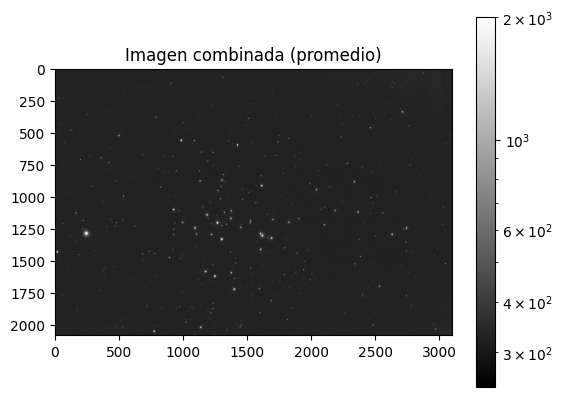

In [24]:
#ahora alinearlos, la primera imagen es la azul, luego
#la roja y luego la verde 
import astroalign as aa

# Convertir a formato nativo little-endian y tipo estable
image_blue  = np.asarray(image_blue,  dtype=np.float64)
image_red   = np.asarray(image_red,   dtype=np.float64)
image_green = np.asarray(image, dtype=np.float64)

# Ahora sí, alineamos
image_red_alineada, footprint_red = aa.register(image_red, image_blue)
image_green_alineada, footprint_green = aa.register(image_green, image_blue)

#promediar las imágenes alineadas para mejorar la relación señal-ruido
image_combinada = (image_blue + image_red_alineada + image_green_alineada) / 3

plt.imshow(image_combinada, cmap="gray", norm="log", vmax=2000)
plt.title("Imagen combinada (promedio)")
plt.colorbar()
plt.show()


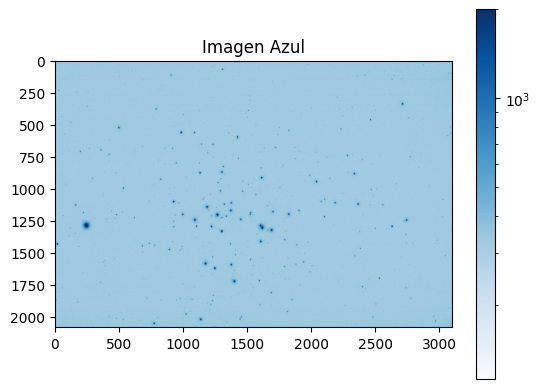

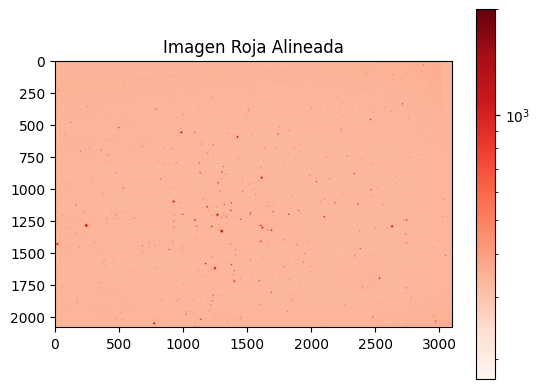

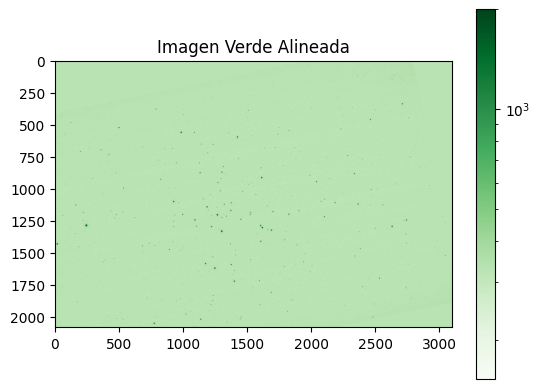

In [27]:
#imprimir las imágenes alineadas con barras de color y
#un filtro bonito

plt.imshow(image_blue, cmap="Blues", norm="log", vmax=2000)
plt.title("Imagen Azul")
plt.colorbar()
plt.show()

plt.imshow(image_red_alineada, cmap="Reds", norm="log", vmax=2000)
plt.title("Imagen Roja Alineada")
plt.colorbar()
plt.show()  

plt.imshow(image_green_alineada, cmap="Greens", norm="log", vmax=2000)  
plt.title("Imagen Verde Alineada")
plt.colorbar()
plt.show()

In [33]:
print("Azul:", photometry_table_blue.colnames)
print("Verde:", photometry_table.colnames)
print("Roja:", photometry_table_red.colnames)

Azul: ['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 'flujo_neto', 'mag_B']
Verde: ['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 'flujo_neto', 'mag_inst']
Roja: ['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 'flujo_neto', 'mag_inst']


In [37]:
import astroalign as aa

try:
    # Registramos la imagen azul y roja sobre la verde (referencia)
    img_b_aligned, _ = aa.register(image_blue, image_green)
    img_r_aligned, _ = aa.register(image_red, image_green)
    
    print("¡Alineación exitosa con Astroalign!")
    # Ahora tendrías que repetir la fotometría de apertura sobre estas nuevas imágenes
    # usando las POSICIONES DE LA VERDE.
except:
    print("Astroalign no pudo encontrar el patrón. Intentemos el plan B.")

¡Alineación exitosa con Astroalign!


In [38]:
from scipy.spatial import KDTree
import pandas as pd

# 1. Extraemos coordenadas
coords_G = np.transpose([photometry_table['xcenter'], photometry_table['ycenter']])
coords_B = np.transpose([photometry_table_blue['xcenter'], photometry_table_blue['ycenter']])
coords_R = np.transpose([photometry_table_red['xcenter'], photometry_table_red['ycenter']])

# 2. Buscamos vecinos (Tolerancia de 100 píxeles por el movimiento que mencionas)
tree_B = KDTree(coords_B)
dist_B, idx_B = tree_B.query(coords_G)

tree_R = KDTree(coords_R)
dist_R, idx_R = tree_R.query(coords_G)

# 3. Filtramos las que sí coinciden
mask = (dist_B < 100) & (dist_R < 100) 

# 4. Creamos el DataFrame para los CMDs
df = pd.DataFrame({
    'G': photometry_table['mag_inst'][mask],
    'B': photometry_table_blue['mag_B'][idx_B[mask]],
    'R': photometry_table_red['mag_inst'][idx_R[mask]]
})

df['B_G'] = df['B'] - df['G']
df['G_R'] = df['G'] - df['R']

print(f"Estrellas listas para el diagrama: {len(df)}")

Estrellas listas para el diagrama: 456


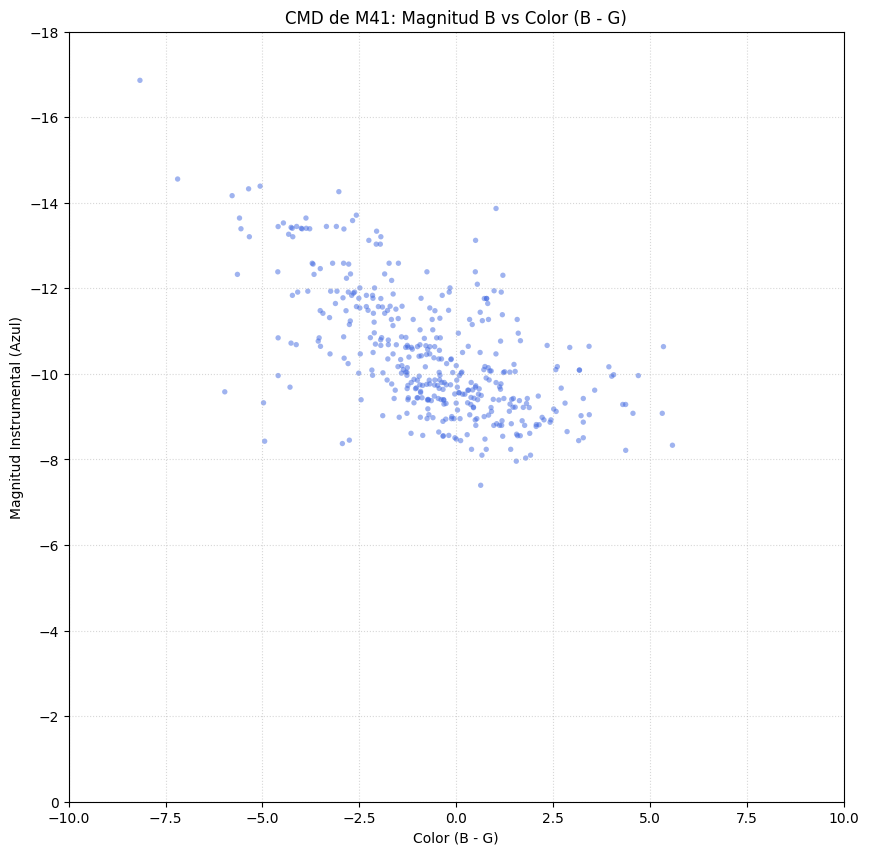

In [54]:
plt.figure(figsize=(10, 10)) # Mantenemos el formato cuadrado

# Graficamos los puntos usando el índice de color Azul-Verde
plt.scatter(df['B_G'], df['B'], s=15, color='royalblue', alpha=0.5, edgecolors='none')

# --- CONFIGURACIÓN DE EJES ---

# Eje X: Color (B - G) de -10 a 10 para centrar la secuencia
plt.xlim(-10, 10)

# Eje Y: Rango de magnitud de -18 a 0 (ajustado a tu solicitud anterior)
plt.ylim(-18, 0) 

# Invertimos el eje Y: Las magnitudes negativas (más brillantes) quedan arriba
plt.gca().invert_yaxis()

# Etiquetas corregidas
plt.xlabel('Color (B - G)')
plt.ylabel('Magnitud Instrumental (Azul)')
plt.title('CMD de M41: Magnitud B vs Color (B - G)')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

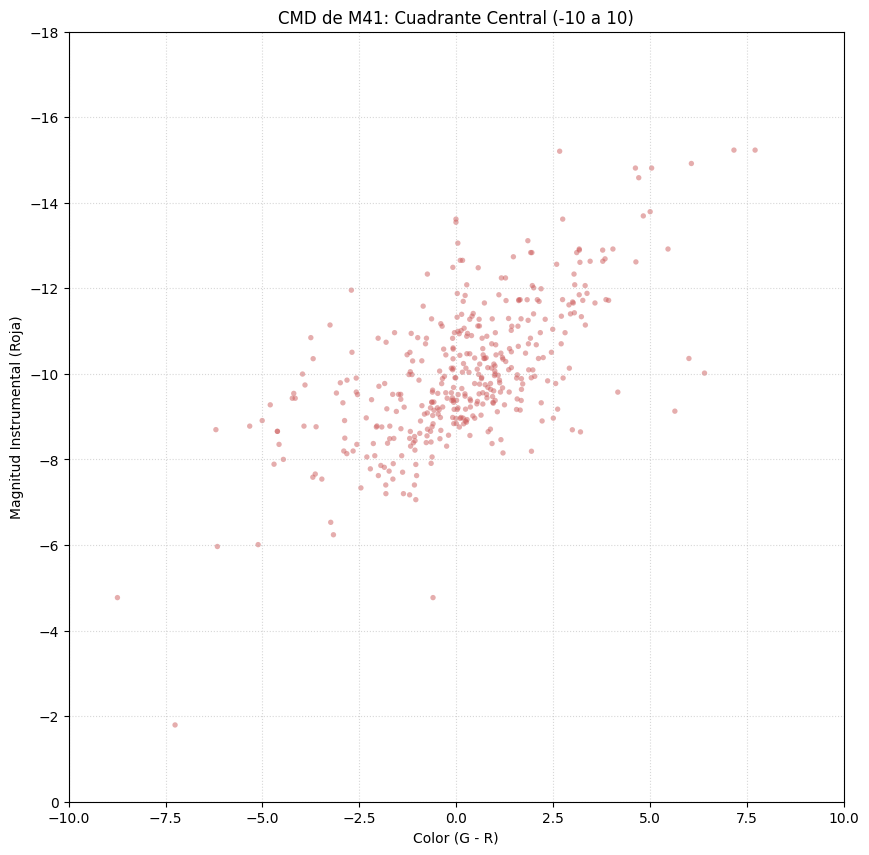

In [53]:
plt.figure(figsize=(10, 10)) # Cambiado a 10,10 para que sea visualmente cuadrado

# Graficamos los puntos
plt.scatter(df['G_R'], df['R'], s=15, color='indianred', alpha=0.5, edgecolors='none')

# --- CONFIGURACIÓN DE EJES ---

# Eje X: de -10 a 10
plt.xlim(-10, 10)

# Eje Y: de -10 a 10 (astronómico)
# Al usar invert_yaxis() después, definimos el rango normal aquí
plt.ylim(-18, 0) 

# Invertimos el eje Y: ahora -10 estará arriba y 10 estará abajo
plt.gca().invert_yaxis()

plt.xlabel('Color (G - R)')
plt.ylabel('Magnitud Instrumental (Roja)')
plt.title('CMD de M41: Cuadrante Central (-10 a 10)')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

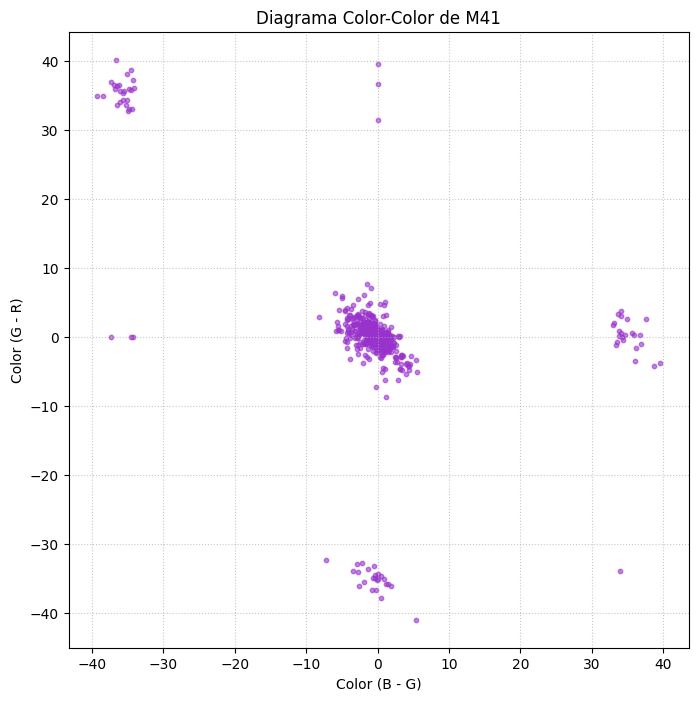

In [42]:
plt.figure(figsize=(8, 8))
plt.scatter(df['B_G'], df['G_R'], s=10, color='darkorchid', alpha=0.6)

plt.xlabel('Color (B - G)')
plt.ylabel('Color (G - R)')
plt.title('Diagrama Color-Color de M41')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

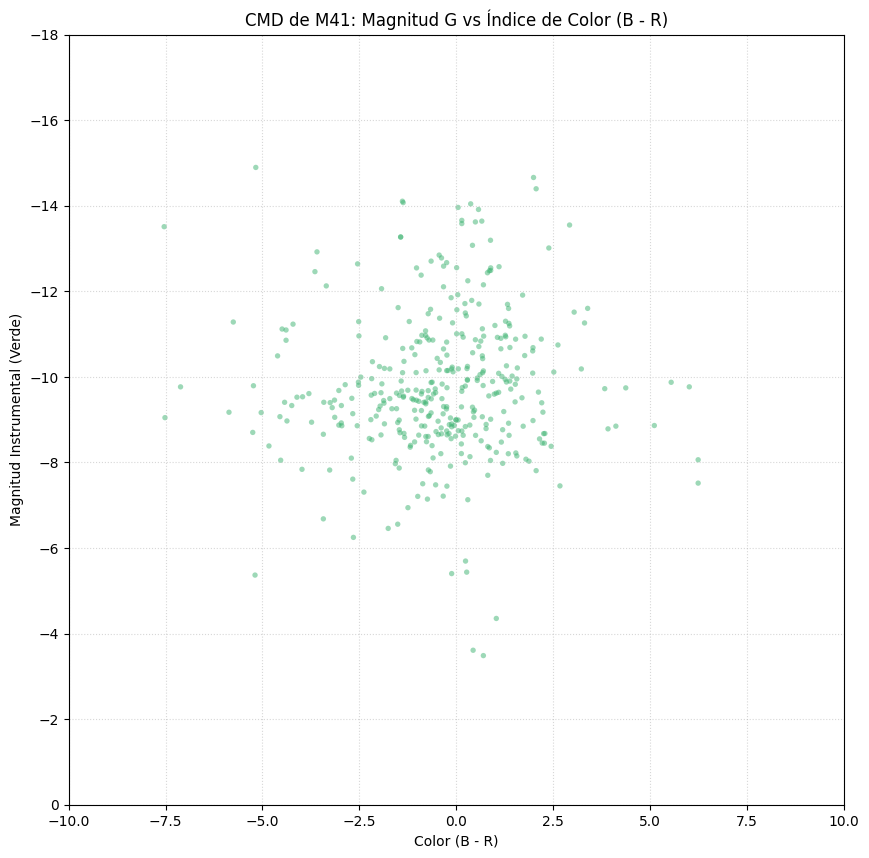

In [55]:
# 1. Calculamos el nuevo índice de color B - R
df['B_R'] = df['B'] - df['R']

# 2. Creamos la gráfica
plt.figure(figsize=(10, 10))

# Graficamos Magnitud Verde (G) vs Color Azul-Rojo (B-R)
plt.scatter(df['B_R'], df['G'], s=15, color='mediumseagreen', alpha=0.5, edgecolors='none')

# --- CONFIGURACIÓN DE EJES ---

# Eje X: Color (B - R) de -10 a 10
plt.xlim(-10, 10)

# Eje Y: Magnitud Verde (G) de -18 a 0
plt.ylim(-18, 0) 

# Invertimos el eje Y para que las estrellas brillantes estén arriba
plt.gca().invert_yaxis()

# Etiquetas
plt.xlabel('Color (B - R)')
plt.ylabel('Magnitud Instrumental (Verde)')
plt.title('CMD de M41: Magnitud G vs Índice de Color (B - R)')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()